In [3]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
systems_cleaned = pd.read_csv('../../../data/core/systems_cleaned.csv')
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source'],
      dtype='str')

In [5]:
systems_cleaned['kg_climate'].value_counts(dropna=False)

kg_climate
Cfa    502
Csb    305
NaN    240
Csa    215
Dfb    189
Dfa    167
Bsk    132
Cfb     27
Bsh     25
Bwh     22
BSk     17
Am       7
Bwk      5
Dfc      3
ET       1
Aw       1
Dsb      1
Name: count, dtype: int64

In [6]:
systems_cleaned[['is_prize_data', 'is_lake_parquet_data', 'is_lake_csv_data', 'system_source']].value_counts()

is_prize_data  is_lake_parquet_data  is_lake_csv_data  system_source
False          False                 True              PV Output        1454
                                                       PVDB              240
               True                  True              PVDAQ General     158
True           False                 False             Prize               5
False          False                 True              PVDAQ General       2
Name: count, dtype: int64

In [ ]:
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
    & systems_cleaned['has_ambient_temperature_data']
]
all_data_ids = set(all_data_systems.system_id)

In [61]:
metrics_dir = Path("../../../data/raw/parquet-metrics/")
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()
metrics_id_set = set(metrics_df.system_id)

In [62]:
my_system_ids = list(all_data_ids.intersection(metrics_id_set))
my_system_ids.sort()
num_ids = len(my_system_ids)
num_ids

39

In [10]:
def metrics_search_for_fragment_df(df: pd.DataFrame, fragment: str):
    fragment = fragment.lower()
    return df[
        (df.loc[:, 'sensor_name'].str.contains(fragment, case=False))
        | (df.loc[:, 'common_name'].str.contains(fragment, case=False))
    ]

In [30]:
def construct_all_parquet_power_aggregator_names():
    global metrics_df, systems_cleaned
    power_data = metrics_search_for_fragment_df(metrics_df, 'pow')
    power_ids = set(power_data.system_id).intersection(set(systems_cleaned.system_id))
    answers_dict = {
        id: [] for id in power_ids
    }
    dc_sensor_names = ['dc_power', 'dc_power_hW', 'dc_power_kW', 'dc_power_1_6',
                       'InvPDC_kW_Avg', 'dc_power_calc']
    ac_sensor_names = ['ac_power', 'ac_power_hW', 'ac_power_kW', 'ac_power_1_6',
                       'InvPAC_kW_Avg', 'ac_power_calc', 'W_avg',
                       'ac_power_metered_kW', 'RTW']
    for sensor_name in dc_sensor_names + ac_sensor_names:
        exact_name_metrics = metrics_df[
                metrics_df['sensor_name'] == sensor_name
        ]
        for id in set(exact_name_metrics['system_id']).intersection(set(systems_cleaned.system_id)):
            relevant_rows_metrics = metrics_df[(metrics_df['system_id']==id)
                                               & (metrics_df['sensor_name']==sensor_name)]
            if len(relevant_rows_metrics.index) > 1:
                raise RuntimeError(f'System {id} has multiple sensors named {sensor_name}!')
            else:
                ind = relevant_rows_metrics.index[0]
                metric_id = relevant_rows_metrics.loc[ind, 'metric_id']
                common_name = relevant_rows_metrics.loc[ind, 'common_name']
                given_unit = relevant_rows_metrics.loc[ind, 'units']
                calc_type = relevant_rows_metrics.loc[ind, 'calc_details']
                answers_dict[id].append({
                    'metric_id': metric_id,
                    'sensor_name': sensor_name,
                    'common_name': common_name,
                    'units': given_unit,
                    'calc_details': calc_type
                })
    # see if missing values
    for id in power_ids:
        if len(answers_dict[id]) == 0:
            print(f'System {id} appears to have no obvious power aggregator name.')
    return answers_dict

Justify the inclusion of 'W_avg', 'RTW' in ac sensor names!

In [ ]:
# show nothing but AC power
assert(set(metrics_df[metrics_df['sensor_name'] == 'W_avg'].common_name) == {'AC power'})
assert(set(metrics_df[metrics_df['sensor_name'] == 'RTW'].common_name) == {'AC power'})

In [66]:
agg_power = construct_all_parquet_power_aggregator_names()

In [111]:
parquet_flags = systems_cleaned[systems_cleaned['is_lake_parquet_data']]
parquet_flags[['has_ac_data', 'has_dc_data']].value_counts()

has_ac_data  has_dc_data
True         False          105
             True            53
Name: count, dtype: int64

**Aside:** What's up here?  System 2 has no ac data in the parquet data, so that should have .has_dc_data = True and .has_ac_data = False, right?

But every parquet system also sent daily summaries to the csv data table, and those are ac power daily averages!  So the ac/dc split is confused with respect to parquet data alone.

In [112]:
# j = 0
# system_id = my_system_ids[j]
system_id = 1431
relevant_rows_systems = systems_cleaned[systems_cleaned['system_id'] == system_id]
for j in relevant_rows_systems.index[0:1]:
    max_dc_capacity = relevant_rows_systems.loc[j, 'dc_capacity_kW']
    system_type = relevant_rows_systems.loc[j, 'simplified_type']
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
# try for total dc power first
power_terms = relevant_rows_metrics[relevant_rows_metrics['sensor_name'] == 'dc_power']
if power_terms.shape[0] > 0:
    first_ind = power_terms.index[0]
    power_metric = power_terms.loc[first_ind, 'metric_id']
    power_type = 'dc'
    power_unit = power_terms.loc[first_ind, 'units']
else:
    power_terms = relevant_rows_metrics[relevant_rows_metrics['sensor_name'] == 'ac_power']
    if power_terms.shape[0] > 0:
        first_ind = power_terms.index[0]
        power_metric = power_terms.loc[first_ind, 'metric_id']
        power_type = 'ac'
        power_unit = power_terms.loc[first_ind, 'units']

power_terms

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1264,1431,5089,dc_power,DC power,W,W,1.0,0.0,dc_voltage*dc_current*3,avg,NaN,NaN,,dc_power__5089


In [113]:
relevant_rows_systems

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source
151,1431,[1431] NREL Windsite PV 1-axis,"Boulder, CO",America/Denver,39.9094,-105.2311,1850.0,1082.85,Dfb,11,...,True,True,True,True,True,True,True,ribbon polycrystalline si,multicrystalline_Si,PVDAQ General


In [114]:
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1263,1431,5086,ac_power,AC power,W,W,1000.0,0.0,kWh_gross*4,avg,NaN,NaN,,ac_power__5086
1264,1431,5089,dc_power,DC power,W,W,1.0,0.0,dc_voltage*dc_current*3,avg,NaN,NaN,,dc_power__5089
1265,1431,5088,dc_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,dc_current__5088
1266,1431,5078,poa_irradiance,Irradiance POA,W/m^2,W/m^2,1.0,0.0,,avg,NaN,NaN,,poa_irradiance__5078
1267,1431,5080,module_temp,Temperature module,C,C,1.0,0.0,,avg,NaN,NaN,,module_temp__5080
1268,1431,5079,ambient_temp,Temperature ambient,C,C,1.0,0.0,,avg,NaN,NaN,,ambient_temp__5079
1269,1431,5087,dc_voltage,DC voltage,V,V,1.0,0.0,,avg,NaN,NaN,,dc_voltage__5087
1270,1431,5084,PR,PR,-,-,1.0,0.0,,NaN,NaN,NaN,,pr__5084
1271,1431,5083,kWh_net,AC energy other,kWh,-,1.0,0.0,,NaN,NaN,NaN,,kwh_net__5083
1272,1431,5082,kWh_gross,AC energy other,kWh,-,1.0,0.0,,NaN,NaN,NaN,,kwh_gross__5082


In [54]:
relevant_rows_metrics[relevant_rows_metrics['sensor_name'].str.contains('pow')]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1297,2,346,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__346


In [ ]:
power_ids = set(metrics_search_for_fragment_df(metrics_df, 'W_avg').system_id)

In [71]:
metered_ids = set(metrics_search_for_fragment_df(metrics_df, 'meter'))

In [72]:
metered_ids.intersection(all_data_ids)

set()

In [80]:
mults = metrics_df[metrics_df['calc_details'].str.contains('\\*')]

In [83]:
mults[mults['common_name'] == 'AC power']

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1263,1431,5086,ac_power,AC power,W,W,1000.0,0.0,kWh_gross*4,avg,NaN,NaN,,ac_power__5086
1281,1433,5069,ac_power,AC power,W,W,1000.0,0.0,kWh_gross*4,avg,NaN,NaN,,ac_power__5069


In [107]:
mults[mults['system_id'] == 1430]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1253,1430,5077,dc_power,DC power,W,W,1.0,0.0,dc_voltage*dc_current*2,avg,NaN,NaN,,dc_power__5077


In [106]:
systems_cleaned[systems_cleaned['system_id']==1430]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_ambient_temperature_data,has_temperature_data,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source
150,1430,[1430] NREL Mesa 1-axis,"Golden, CO",America/Denver,39.7438,-105.1779,1831.0,720.72,BSk,12,...,True,True,True,True,True,True,True,SJT,heterojunction,PVDAQ General


In [108]:
mults.iloc[65:70, :]

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1048,1369,3175,inv9_dc_power,DC power,W,W,1.0,0.0,inv9_dc_voltage*inv9_dc_current,avg,NaN,NaN,,inv9_dc_power__3175
1083,1403,5033,dc_power,DC power,W,W,1.0,0.0,inv1_dc_voltage*inv1_dc_current1+inv1_dc_volta...,avg,NaN,NaN,,dc_power__5033
1160,1419,5143,dc_power,DC power,W,W,1.0,0.0,dc_voltage_1_Vdc*dc_current_1_Idc+dc_voltage_2...,avg,NaN,NaN,AE_HID=0,dc_power__5143
1172,1420,5144,dc_power,DC power,W,W,1.0,0.0,dc_voltage_Vdc*dc_current_I2,avg,NaN,NaN,AE_HID=0,dc_power__5144
1253,1430,5077,dc_power,DC power,W,W,1.0,0.0,dc_voltage*dc_current*2,avg,NaN,NaN,,dc_power__5077


In [77]:
metrics_df['calc_details'].value_counts()

calc_details
                                                                                                                                       1649
inv1_dc_voltage*inv1_dc_current                                                                                                           7
inv2_dc_voltage*inv2_dc_current                                                                                                           7
dc_current_1*dc_voltage_1                                                                                                                 6
dc_current_2*dc_voltage_2                                                                                                                 6
dc_current_3*dc_voltage_3                                                                                                                 6
inv3_dc_voltage*inv3_dc_current                                                                                                           5
inv4_dc

In [76]:
metrics_search_for_fragment_df(metrics_df, 'calc')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
589,1300,36,dc_power_calc,DC power,W,W,1.0,0.0,dc_current*dc_voltage,avg,NaN,NaN,,dc_power_calc__36
622,1305,63,dc_power_1_calc,DC power,W,W,1.0,0.0,dc_current_1*dc_voltage_1,avg,NaN,NaN,,dc_power_1_calc__63
626,1305,69,dc_power_2_calc,DC power,W,W,1.0,0.0,dc_current_2*dc_voltage_2,avg,NaN,NaN,,dc_power_2_calc__69
630,1305,75,dc_power_3_calc,DC power,W,W,1.0,0.0,dc_current_3*dc_voltage_3,avg,NaN,NaN,,dc_power_3_calc__75
657,1306,233,dc_power_1_calc,DC power,W,W,1.0,0.0,dc_current_1*dc_voltage_1,avg,NaN,NaN,,dc_power_1_calc__233
658,1306,234,dc_power_2_calc,DC power,W,W,1.0,0.0,dc_current_2*dc_voltage_2,avg,NaN,NaN,,dc_power_2_calc__234
659,1306,235,dc_power_3_calc,DC power,W,W,1.0,0.0,dc_current_3*dc_voltage_3,avg,NaN,NaN,,dc_power_3_calc__235
660,1306,236,dc_power_4_calc,DC power,W,W,1.0,0.0,dc_current_4*dc_voltage_4,avg,NaN,NaN,,dc_power_4_calc__236
661,1306,237,dc_power_5_calc,DC power,W,W,1.0,0.0,dc_current_5*dc_voltage_5,avg,NaN,NaN,,dc_power_5_calc__237
662,1306,238,dc_power_6_calc,DC power,W,W,1.0,0.0,dc_current_6*dc_voltage_6,avg,NaN,NaN,,dc_power_6_calc__238


In [75]:
metrics_search_for_fragment_df(metrics_df, 'factor')

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
88,1200,4198,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__4198
94,1201,2799,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__2799
141,1202,2805,power_factor,AC other,-,-,1.000,0.0,,NaN,NaN,NaN,,power_factor__2805
154,1203,2901,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__2901
155,1203,2908,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__2908
449,1276,3038,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3038
464,1277,3053,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__3053
484,1278,3068,inv1_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv1_power_factor__3068
485,1278,3077,inv2_power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,inv2_power_factor__3077
526,1284,957,power_factor,AC other,-,-,1.000,0.0,,avg,NaN,NaN,,power_factor__957


In [70]:
for id in metered_ids:
    print(id)
    relevant_rows_metrics = metrics_df[metrics_df['system_id'] == id]
    for term in agg_power[id]:
        print(term)
    

1200
{'metric_id': np.int32(2752), 'sensor_name': 'dc_power', 'common_name': 'DC power', 'units': 'W', 'calc_details': ''}
{'metric_id': np.int32(2751), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'ac_power_metered_kW'}
{'metric_id': np.int32(4197), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': ''}
1202
{'metric_id': np.int32(2841), 'sensor_name': 'dc_power', 'common_name': 'DC power', 'units': 'W', 'calc_details': 'inv1_dc_power+inv2_dc_power+inv3_dc_power+inv4_dc_power+inv5_dc_power+inv6_dc_power'}
{'metric_id': np.int32(2840), 'sensor_name': 'ac_power', 'common_name': 'AC power', 'units': 'W', 'calc_details': 'inv1_ac_power+inv2_ac_power+inv3_ac_power+inv4_ac_power+inv5_ac_power+inv6_ac_power'}
{'metric_id': np.int32(2802), 'sensor_name': 'ac_power_metered_kW', 'common_name': 'AC power', 'units': 'W', 'calc_details': ''}
1203
{'metric_id': np.int32(2890), 'sensor_name': 'dc_power', 'common_name'

In [74]:
ac_power_but_not_from_inverter_ids = {1203, 1208, 1239, 1275, 1283}

In [145]:
metrics_df[metrics_df['sensor_name'] == 'RTW'].common_name.value_counts()

common_name
AC power    18
Name: count, dtype: int64

In [129]:
parquet_data = systems_cleaned[systems_cleaned['is_lake_parquet_data']]
parquet_data_ids = set(parquet_data.system_id)
no_power_ids = parquet_data_ids.difference(power_ids)
no_power_ids

{1216,
 1218,
 1220,
 1222,
 1224,
 1226,
 1228,
 1294,
 1295,
 1296,
 1297,
 1298,
 1299,
 1301,
 1302,
 1303,
 1304,
 1309,
 1311,
 1334,
 1335,
 1336,
 1337,
 1338,
 1339,
 1340,
 1342,
 1343,
 1344,
 1345,
 1346,
 1347,
 1348,
 1349,
 1350,
 1351,
 1352,
 1353,
 1354,
 1355,
 1356,
 1357,
 1358,
 1359,
 1360,
 1361,
 1362,
 1363,
 1364}

In [44]:
power_unit = 'W'

In [54]:
if power_terms.shape[0] > 0:
    # download 
    access_system_dir = Path(f'../../data_ds_project/systems/parquet/{system_id}/')
    current_pq = pq.ParquetDataset(access_system_dir,
                                   filters= [
                                       ('metric_id', 'in', [2889, 2890, 2911])
                                   ])
    current_df = current_pq.read().to_pandas()
    # cleaning
    current_df = current_df.drop(columns=['utc_measured_on'])
    current_df.loc[:, 'mean_value'] = current_df.groupby(['measured_on', 'metric_id'])['value'].transform('mean')
    current_df = current_df.drop(columns = 'value')
    current_df = current_df.drop_duplicates()
    current_df_wide = current_df.pivot(
        index='measured_on',
        columns='metric_id',
        values='mean_value'
    )
    # current_df_wide = current_df_wide.rename(
    #     columns = {power_metric: f'{power_type}_power'}
    # )
    current_df_wide = current_df_wide.rename(
        columns = {2889: 'ac_power', 2890: 'dc_power', 2911: 'ac_inverter_power'}
    )
    # convert to kW
    # if power_unit == 'W':
    #     current_df_wide[f'{power_type}_power'] = current_df_wide[f'{power_type}_power']/1000
    # elif power_unit.lower() != 'kw':
    #     raise ValueError('Unidentified units!')

In [55]:
max_dc_capacity

np.float64(197.47)

In [56]:
current_df_wide

metric_id,ac_power,dc_power,ac_inverter_power
measured_on,,,
2011-01-19 09:00:03,-160.0,NaN,NaN
2011-01-19 09:15:03,-160.0,NaN,NaN
2011-01-19 09:30:03,-160.0,NaN,NaN
2011-01-19 09:45:03,-160.0,NaN,NaN
2011-01-19 10:00:03,-160.0,NaN,NaN
...,...,...,...
2018-08-04 06:35:02,840.0,1600.0,800.0
2018-08-04 06:40:02,2360.0,3200.0,2200.0
2018-08-04 06:45:02,3640.0,4500.0,3500.0


In [57]:
current_df_wide.describe()

metric_id,ac_power,dc_power,ac_inverter_power
count,1.142389e+06,1.137032e+06,1.137032e+06
mean,2.854380e+04,3.005507e+04,2.858010e+04
std,4.695942e+04,4.892966e+04,4.733088e+04
min,-1.480000e+03,-8.000000e+02,-1.900000e+03
25%,-1.600000e+02,0.000000e+00,-5.000000e+02
50%,-1.200000e+02,0.000000e+00,-4.000000e+02
75%,3.976000e+04,4.200000e+04,4.020000e+04
max,1.995200e+05,2.104000e+05,2.004000e+05


In [33]:
# add relative power calculation
current_df_wide.loc[:, 'power_proportion'] = current_df_wide['dc_power'] / max_dc_capacity

In [34]:
current_df_wide

metric_id,dc_power,power_proportion
measured_on,,
2011-01-24 11:15:00,0.660,0.004710
2011-01-24 11:18:00,0.676,0.004824
2011-01-24 11:21:00,0.681,0.004859
2011-01-24 11:24:00,0.698,0.004981
2011-01-24 11:27:00,0.706,0.005038
...,...,...
2020-07-26 16:40:00,88.500,0.631511
2020-07-26 16:45:00,66.100,0.471671
2020-07-26 16:50:00,64.100,0.457400


In [35]:
current_df_wide['dc_power']

measured_on
2011-01-24 11:15:00     0.660
2011-01-24 11:18:00     0.676
2011-01-24 11:21:00     0.681
2011-01-24 11:24:00     0.698
2011-01-24 11:27:00     0.706
                        ...  
2020-07-26 16:40:00    88.500
2020-07-26 16:45:00    66.100
2020-07-26 16:50:00    64.100
2020-07-26 16:55:00    53.400
2020-07-26 17:00:00    64.500
Name: dc_power, Length: 1349176, dtype: float64

In [36]:
current_df_wide['power_proportion'].describe()

count    1.349176e+06
mean     2.270130e-02
std      1.033888e-01
min     -1.427144e-05
25%      0.000000e+00
50%      0.000000e+00
75%      2.761524e-03
max      1.023976e+00
Name: power_proportion, dtype: float64

In [37]:
current_df_wide['power_proportion'].max()

np.float64(1.023976023976024)

In [36]:
# filter to data > 0.5 kW
power_active = current_df_wide[current_df_wide['dc_power'] >= 0.5]

In [37]:
power_active.shape

(83551, 2)

In [38]:
power_active = power_active.reset_index()
power_active['measured_on'].dtype

dtype('<M8[ns]')

In [39]:
power_active.loc[:, 'year'] = power_active['measured_on'].dt.year
power_active.loc[:, 'month'] = power_active['measured_on'].dt.month
power_active.loc[:, 'day'] = power_active['measured_on'].dt.day

In [46]:
power_active.loc[:, 'date'] = power_active['measured_on'].dt.date

In [45]:
power_active['measured_on'].dt.date

0        2010-10-03
1        2010-10-03
2        2010-10-03
3        2010-10-03
4        2010-10-03
            ...    
83546    2013-12-01
83547    2013-12-01
83548    2013-12-01
83549    2013-12-01
83550    2013-12-01
Name: measured_on, Length: 83551, dtype: object

In [47]:
power_active['daily_average'] = power_active.groupby(['date'])['dc_power'].transform('mean')

In [48]:
power_active['daily_average_proportion'] = power_active['daily_average'] / max_dc_capacity

In [49]:
power_active.head()

metric_id,measured_on,dc_power,power_proportion,year,month,day,daily_average,daily_average_proportion,date
0,2010-10-03 12:15:12,7.467470,0.144048,2010,10,3,10.241658,0.197563,2010-10-03
1,2010-10-03 12:30:12,10.081308,0.194470,2010,10,3,10.241658,0.197563,2010-10-03
2,2010-10-03 12:45:12,8.917504,0.172020,2010,10,3,10.241658,0.197563,2010-10-03
3,2010-10-03 13:00:13,9.794935,0.188946,2010,10,3,10.241658,0.197563,2010-10-03
4,2010-10-03 13:15:13,17.392150,0.335497,2010,10,3,10.241658,0.197563,2010-10-03


In [50]:
power_daily = power_active[['date', 'daily_average_proportion']].drop_duplicates()

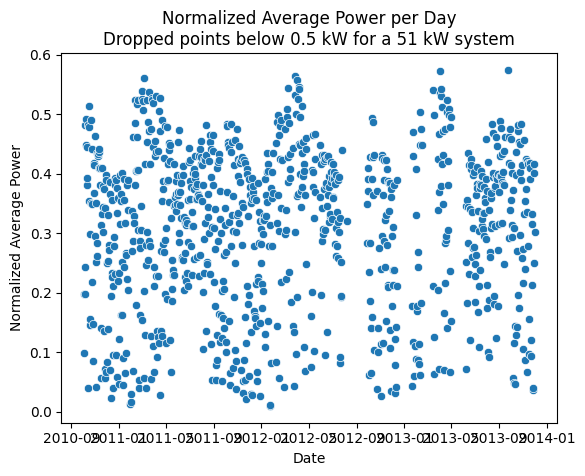

In [55]:
sns.scatterplot(
    data=power_daily,
    x='date',
    y='daily_average_proportion'
)
plt.xlabel('Date')
plt.ylabel('Normalized Average Power')
plt.title('Normalized Average Power per Day\n'
          + 'Dropped points below 0.5 kW for a 51 kW system')
plt.show()